In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

# Project root
PROJECT_ROOT = Path("..")

TRAIN_DIR = PROJECT_ROOT / "data" / "train"
TEST_DIR = PROJECT_ROOT / "data" / "test"

print("Train directory:", TRAIN_DIR.resolve())
print("Test directory :", TEST_DIR.resolve())

Train directory: C:\Users\YASWANTH\Desktop\amazon-ml-er\data\train
Test directory : C:\Users\YASWANTH\Desktop\amazon-ml-er\data\test


In [3]:
print("TRAIN FILES")
for f in TRAIN_DIR.glob("*.tsv"):
    print(f.name)

print("\nTEST FILES")
for f in TEST_DIR.glob("*.tsv"):
    print(f.name)

TRAIN FILES
train_ground_truth.tsv
train_source1.tsv
train_source2.tsv
train_source3.tsv

TEST FILES
test_source1.tsv
test_source2.tsv
test_source3.tsv


In [4]:
SAMPLE_SIZE = 100_000

def load_sample(path, nrows=SAMPLE_SIZE):
    return pd.read_csv(
        path,
        sep="\t",
        nrows=nrows,
        low_memory=False
    )

s1_sample = load_sample(
    TRAIN_DIR / "train_source1.tsv"
)

s2_sample = load_sample(
    TRAIN_DIR / "train_source2.tsv"
)

s3_sample = load_sample(
    TRAIN_DIR / "train_source3.tsv"
)

gt_sample = load_sample(
    TRAIN_DIR / "train_ground_truth.tsv"
)

print("S1:", s1_sample.shape)
print("S2:", s2_sample.shape)
print("S3:", s3_sample.shape)
print("GT:", gt_sample.shape)

S1: (100000, 4)
S2: (100000, 4)
S3: (100000, 4)
GT: (100000, 2)


In [5]:
datasets = {
    "Source 1": s1_sample,
    "Source 2": s2_sample,
    "Source 3": s3_sample,
    "Ground Truth": gt_sample
}

for name, df in datasets.items():
    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)
    print("Shape:", df.shape)
    print("Columns:")
    print(df.columns.tolist())


Source 1
Shape: (100000, 4)
Columns:
['entity_id', 'business_name', 'business_address', 'country']

Source 2
Shape: (100000, 4)
Columns:
['entity_id', 'business_name', 'business_address', 'country']

Source 3
Shape: (100000, 4)
Columns:
['entity_id', 'business_name', 'business_address', 'country']

Ground Truth
Shape: (100000, 2)
Columns:
['source1_entity_id', 'matched_entity_ids']


In [6]:
for name, df in datasets.items():
    print("\n", "=" * 70)
    print(name)
    print("=" * 70)
    display(df.head())


Source 1


,entity_id,business_name,business_address,country
0,S1-925783039,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",US
1,S1-773889195,Prime Money,"17560 Ellis Road, Tahlequah, OK",US
2,S1-377745466,B+ Retail Inc,"1712 Montebello Avenue, Phoenix, AZ",US
3,S1-133037285,Christ Chapel,"2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD",US
4,S1-755362802,Prabhav Business Center,"797, Lake Town Block A, Kolkata, Howrah, West ...",India



Source 2


,entity_id,business_name,business_address,country
0,S2-166376419,राम मार्केटिंग प्राइवेट लिमिटेड,"KH NO. -570/13, NEW DELHI, WEST DELHI, Delhi",India
1,S2-764573417,-- Holloway Peak Inc Seafood,"105 ELM ST, MORGANTON, NC",US
2,S2-639257739,आदित्य प्रॉपर्टीज एलएलपी,"G-3/571, GULMOHAR COLONY, BHOPAL, Madhya Pradesh",India
3,S2-163963287,Summit Inc,"GREENSBORO, NC, 19 1/2 STARDUST TRAIL",US
4,S2-49942811,Delta Tetlecommunication Inc,"914 PIERPONT AVE, CLEVELAND, OH",US



Source 3


,entity_id,business_name,business_address,country
0,S3-202863386,wilfordhancock.com,"Mack Rd, Haltom City, Texas",US
1,S3-859268022,International South Consultants Private Ltd,NaN,India
2,S3-22467283,LLC Moncada Léarning Center,"5780 Fawn Ct, Fort Worth, Texas",US
3,S3-671162755,Moyna's Coffee,"1 Ivanhoe Ave, PO Box 6009, Cincinnati, Ohio",US
4,S3-960981775,Pvt. EFS Print Ventures Ltd.,"Door No 183, 41St Cross, 22Nd Main 9Th Block J...",India



Ground Truth


,source1_entity_id,matched_entity_ids
0,S1-965667,"S2-681193310,S2-743505751,S3-775321672,S3-1129..."
1,S1-55344266,"S2-249013014,S2-197070651,S3-478195123,S3-3843..."
2,S1-343815751,"S2-790675320,S2-479876582,S3-878454467"
3,S1-656753428,"S2-153058913,S2-24659151,S3-679606215"
4,S1-102811957,"S2-478959098,S2-553508714,S2-625774905,S3-7280..."


In [7]:
for name, df in datasets.items():
    print("\n", "=" * 70)
    print(name)
    print("=" * 70)

    display(
        pd.DataFrame({
            "dtype": df.dtypes.astype(str),
            "unique_values": df.nunique(),
            "missing": df.isna().sum(),
            "missing_%": (
                df.isna().mean() * 100
            ).round(2)
        })
    )


Source 1


,dtype,unique_values,missing,missing_%
entity_id,str,100000,0,0.0
business_name,str,90403,0,0.0
business_address,str,99713,0,0.0
country,str,2,0,0.0



Source 2


,dtype,unique_values,missing,missing_%
entity_id,str,100000,0,0.00
business_name,str,98731,0,0.00
business_address,str,96377,3330,3.33
country,str,2,0,0.00



Source 3


,dtype,unique_values,missing,missing_%
entity_id,str,100000,0,0.00
business_name,str,98835,0,0.00
business_address,str,96443,3352,3.35
country,str,2,0,0.00



Ground Truth


,dtype,unique_values,missing,missing_%
source1_entity_id,str,100000,0,0.00
matched_entity_ids,str,94406,5594,5.59


In [8]:
def missing_report(df, name):
    result = pd.DataFrame({
        "Missing Count": df.isna().sum(),
        "Missing %": (df.isna().mean() * 100).round(2)
    })

    result = result.sort_values(
        "Missing %",
        ascending=False
    )

    print(f"\n{name}")
    display(result)


for name, df in datasets.items():
    missing_report(df, name)


Source 1


,Missing Count,Missing %
entity_id,0,0.0
business_name,0,0.0
business_address,0,0.0
country,0,0.0



Source 2


,Missing Count,Missing %
business_address,3330,3.33
entity_id,0,0.00
business_name,0,0.00
country,0,0.00



Source 3


,Missing Count,Missing %
business_address,3352,3.35
entity_id,0,0.00
business_name,0,0.00
country,0,0.00



Ground Truth


,Missing Count,Missing %
matched_entity_ids,5594,5.59
source1_entity_id,0,0.00


In [9]:
for name, df in datasets.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print("Total rows:", len(df))
    print("Duplicate rows:", df.duplicated().sum())
    print(
        "Duplicate %:",
        round(df.duplicated().mean() * 100, 2)
    )


Source 1
Total rows: 100000
Duplicate rows: 0
Duplicate %: 0.0

Source 2
Total rows: 100000
Duplicate rows: 0
Duplicate %: 0.0

Source 3
Total rows: 100000
Duplicate rows: 0
Duplicate %: 0.0

Ground Truth
Total rows: 100000
Duplicate rows: 0
Duplicate %: 0.0


In [10]:
for name, df in datasets.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    for col in df.columns:

        unique = df[col].nunique(dropna=True)

        print(
            f"{col:30} "
            f"unique={unique:,} "
            f"ratio={unique / max(len(df),1):.4f}"
        )


Source 1
entity_id                      unique=100,000 ratio=1.0000
business_name                  unique=90,403 ratio=0.9040
business_address               unique=99,713 ratio=0.9971
country                        unique=2 ratio=0.0000

Source 2
entity_id                      unique=100,000 ratio=1.0000
business_name                  unique=98,731 ratio=0.9873
business_address               unique=96,377 ratio=0.9638
country                        unique=2 ratio=0.0000

Source 3
entity_id                      unique=100,000 ratio=1.0000
business_name                  unique=98,835 ratio=0.9883
business_address               unique=96,443 ratio=0.9644
country                        unique=2 ratio=0.0000

Ground Truth
source1_entity_id              unique=100,000 ratio=1.0000
matched_entity_ids             unique=94,406 ratio=0.9441


In [11]:
for name, df in datasets.items():

    numeric_cols = df.select_dtypes(
        include=np.number
    ).columns

    if len(numeric_cols) > 0:

        print("\n" + "=" * 70)
        print(name)
        print("=" * 70)

        display(
            df[numeric_cols].describe().T
        )

In [12]:
def text_length_report(df):

    result = []

    for col in df.select_dtypes(
        include=["object"]
    ).columns:

        lengths = (
            df[col]
            .fillna("")
            .astype(str)
            .str.len()
        )

        result.append({
            "column": col,
            "mean_length": lengths.mean(),
            "median_length": lengths.median(),
            "min_length": lengths.min(),
            "max_length": lengths.max()
        })

    return pd.DataFrame(result)


for name, df in datasets.items():

    print("\n", "=" * 70)
    print(name)
    print("=" * 70)

    display(
        text_length_report(df)
    )


Source 1


C:\Users\YASWANTH\AppData\Local\Temp\ipykernel_35792\3709924843.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(


,column,mean_length,median_length,min_length,max_length
0,entity_id,11.89126,12.0,6,12
1,business_name,24.04487,24.0,3,71
2,business_address,52.08069,41.0,13,222
3,country,3.20330,2.0,2,5



Source 2


C:\Users\YASWANTH\AppData\Local\Temp\ipykernel_35792\3709924843.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(


...

C:\Users\YASWANTH\AppData\Local\Temp\ipykernel_35792\3709924843.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(


,column,mean_length,median_length,min_length,max_length
0,entity_id,11.89050,12.0,8,12
1,business_name,25.19804,25.0,2,80
2,business_address,46.82833,42.0,0,198
3,country,3.21413,2.0,2,5



Ground Truth


C:\Users\YASWANTH\AppData\Local\Temp\ipykernel_35792\3709924843.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(


,column,mean_length,median_length,min_length,max_length
0,source1_entity_id,11.88894,12.0,8,12
1,matched_entity_ids,43.65147,38.0,0,140


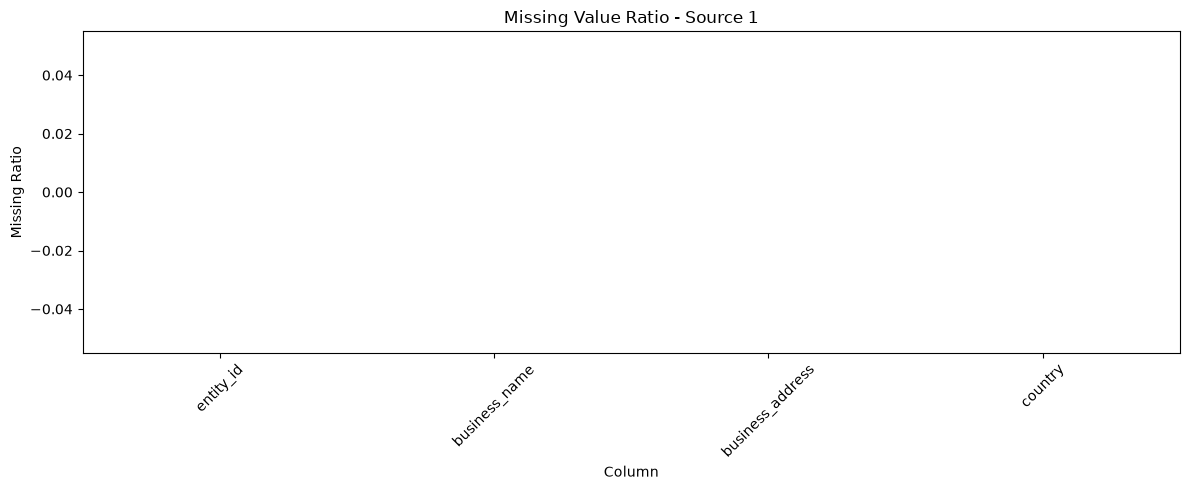

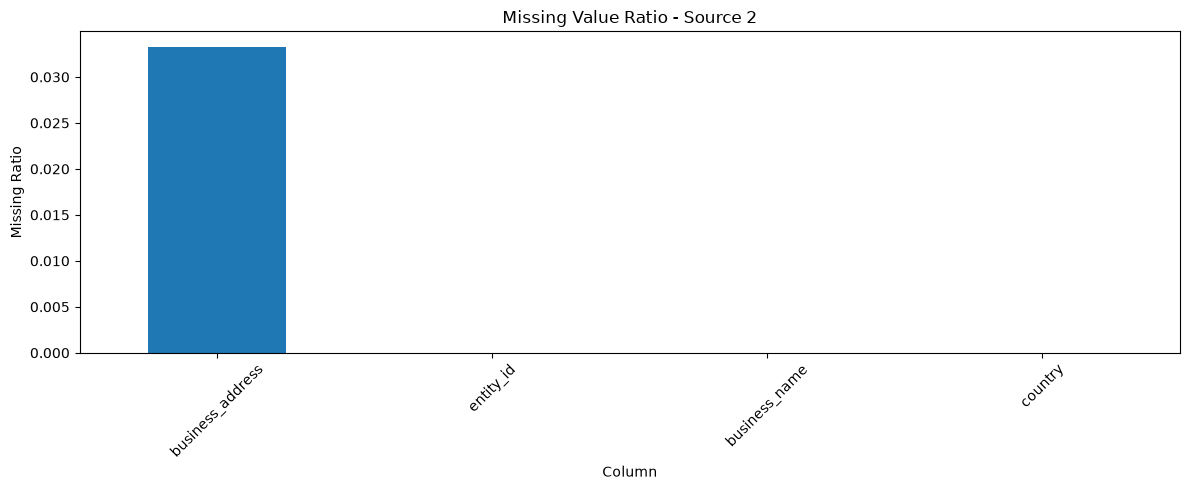

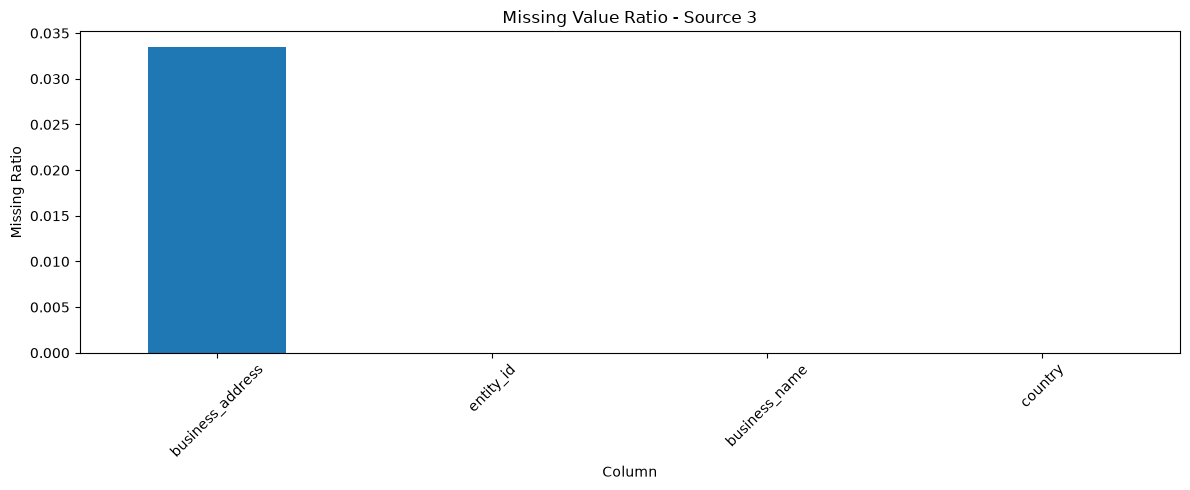

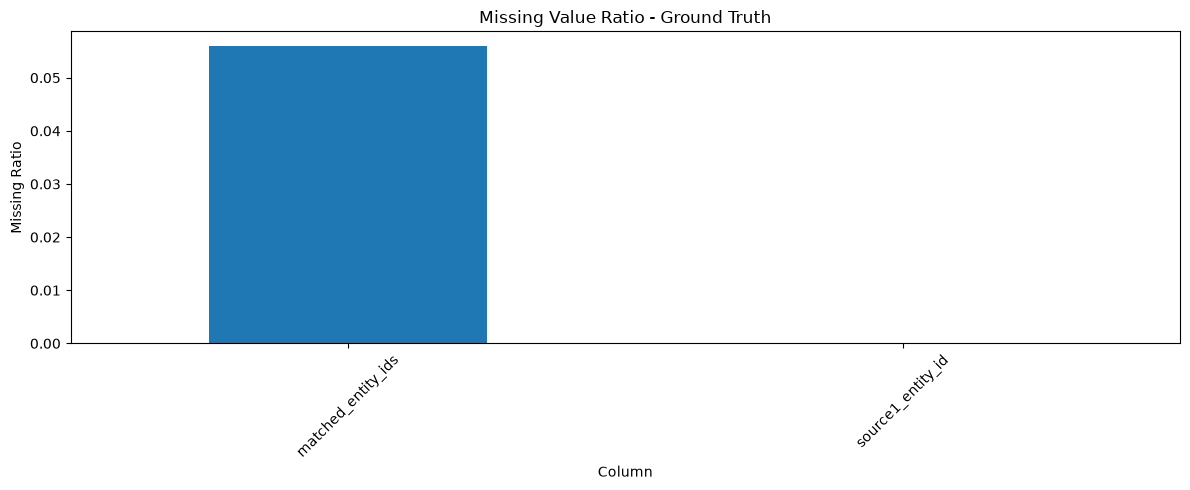

In [13]:
for name, df in datasets.items():

    missing = (
        df.isna()
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(12, 5))

    missing.plot(kind="bar")

    plt.title(
        f"Missing Value Ratio - {name}"
    )

    plt.ylabel("Missing Ratio")
    plt.xlabel("Column")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

C:\Users\YASWANTH\AppData\Local\Temp\ipykernel_35792\835320648.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(


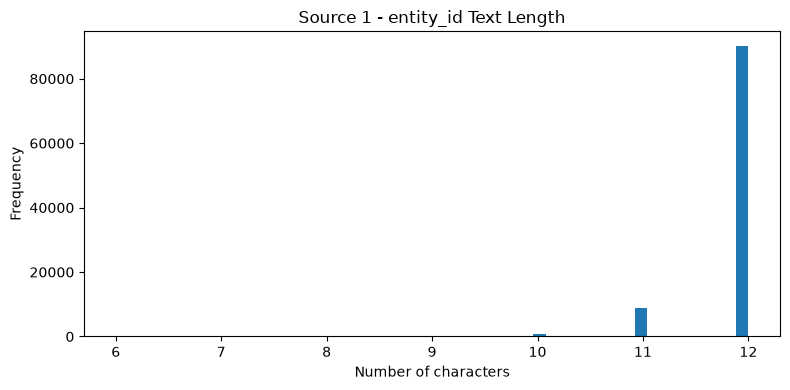

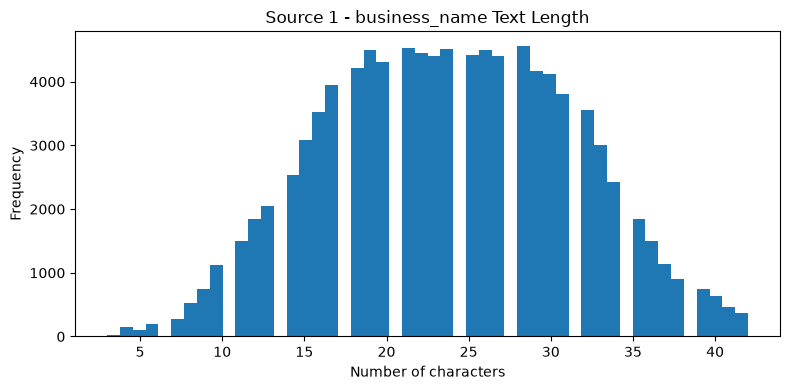

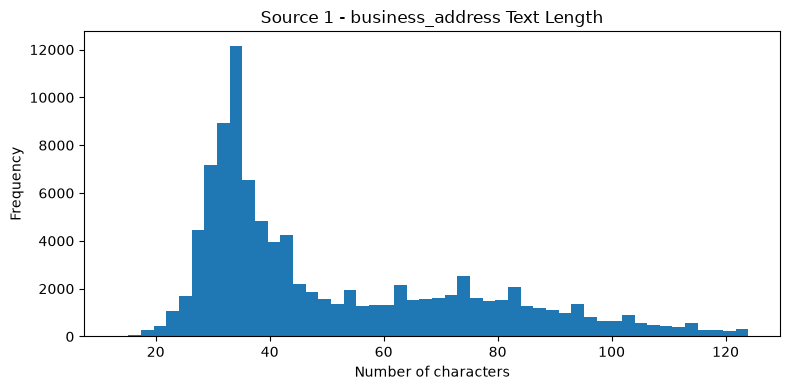

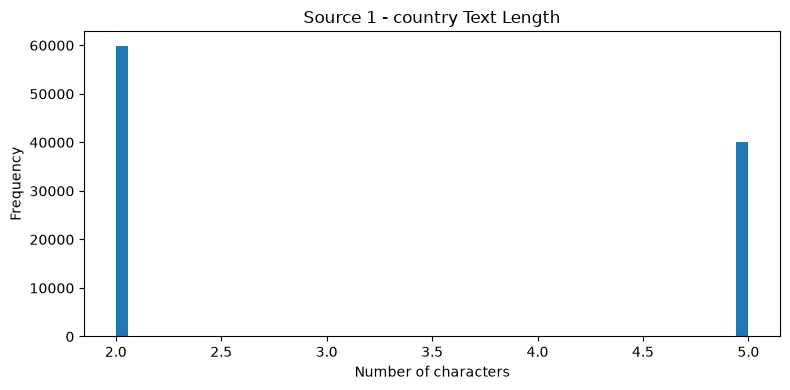

C:\Users\YASWANTH\AppData\Local\Temp\ipykernel_35792\835320648.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(


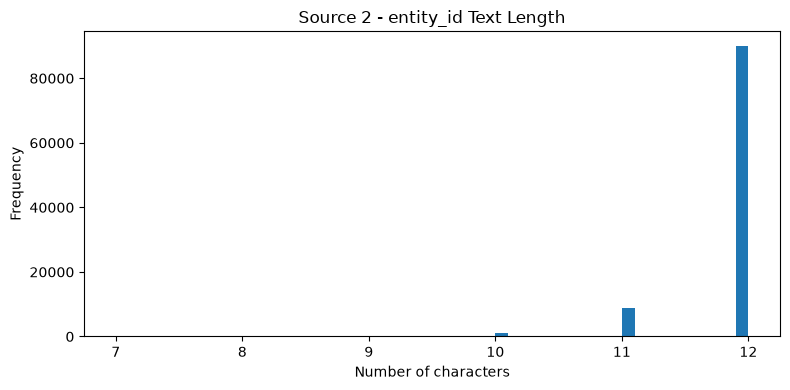

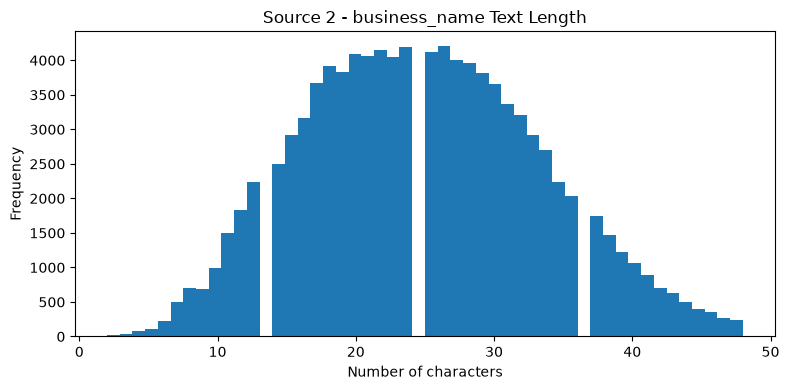

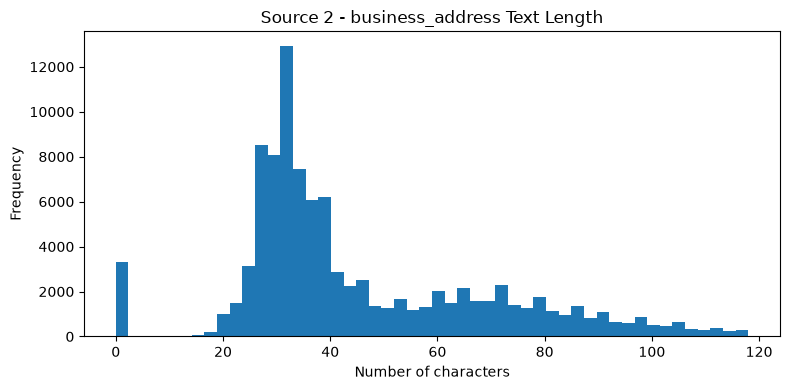

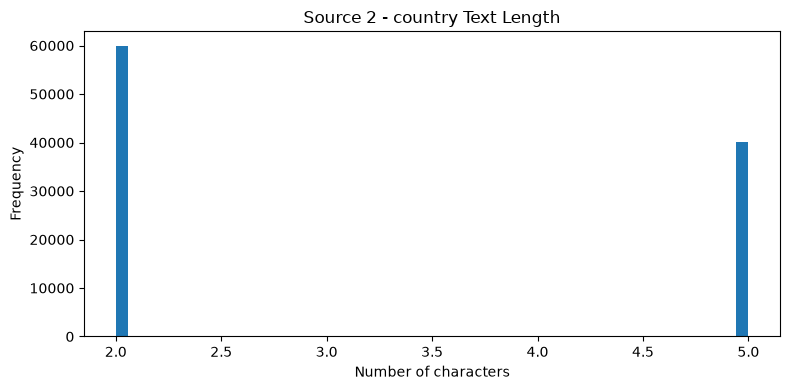

C:\Users\YASWANTH\AppData\Local\Temp\ipykernel_35792\835320648.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(


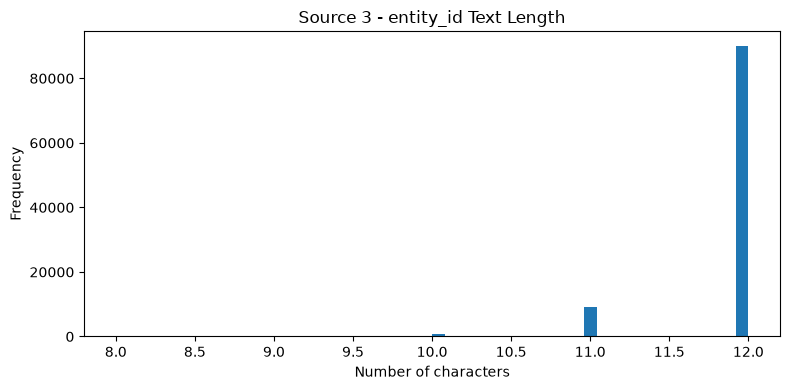

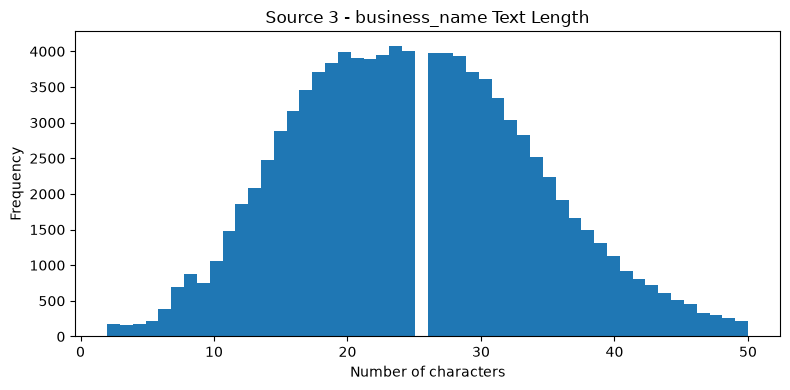

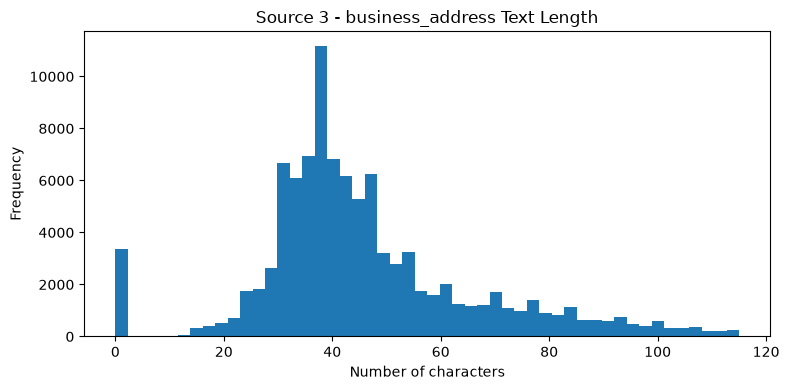

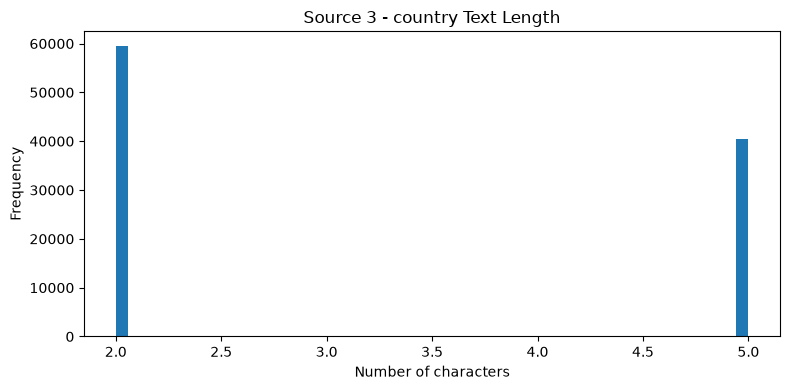

C:\Users\YASWANTH\AppData\Local\Temp\ipykernel_35792\835320648.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(


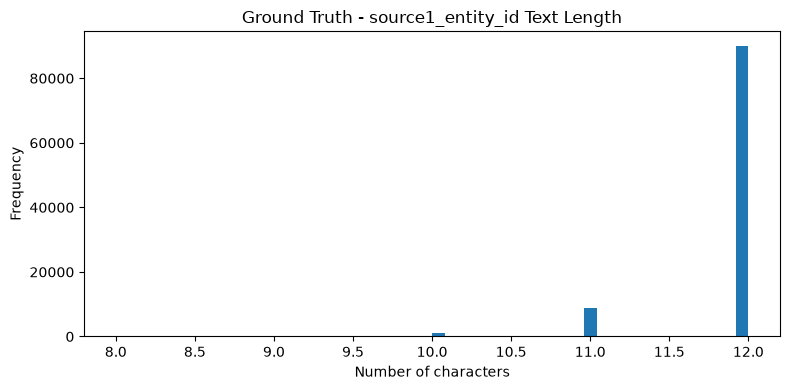

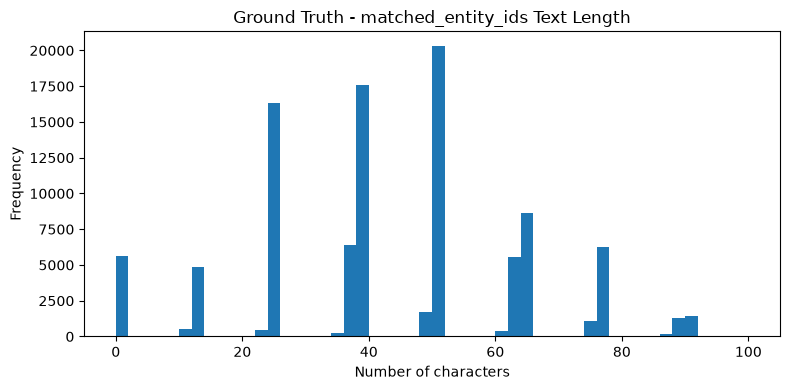

In [14]:
for name, df in datasets.items():

    text_cols = df.select_dtypes(
        include=["object"]
    ).columns

    for col in text_cols:

        lengths = (
            df[col]
            .fillna("")
            .astype(str)
            .str.len()
        )

        # Avoid extreme outliers affecting the plot
        upper = lengths.quantile(0.99)

        plt.figure(figsize=(8, 4))

        plt.hist(
            lengths[lengths <= upper],
            bins=50
        )

        plt.title(
            f"{name} - {col} Text Length"
        )

        plt.xlabel("Number of characters")
        plt.ylabel("Frequency")

        plt.tight_layout()
        plt.show()

In [15]:
print(gt_sample.columns.tolist())

display(gt_sample.head(10))

['source1_entity_id', 'matched_entity_ids']


,source1_entity_id,matched_entity_ids
0,S1-965667,"S2-681193310,S2-743505751,S3-775321672,S3-1129..."
1,S1-55344266,"S2-249013014,S2-197070651,S3-478195123,S3-3843..."
2,S1-343815751,"S2-790675320,S2-479876582,S3-878454467"
3,S1-656753428,"S2-153058913,S2-24659151,S3-679606215"
4,S1-102811957,"S2-478959098,S2-553508714,S2-625774905,S3-7280..."
5,S1-18727616,"S2-755677256,S3-187831601,S3-641489370,S3-4762..."
6,S1-318373630,"S2-660036492,S3-804600254"
7,S1-86989137,"S3-274817120,S3-312496301"
8,S1-29845983,"S2-648035184,S3-588502663"
9,S1-789009573,"S2-383871912,S3-74481402,S3-576451439"


In [16]:
for col in gt_sample.columns:

    print("\nColumn:", col)
    print("Unique values:", gt_sample[col].nunique())

    display(
        gt_sample[col]
        .value_counts(dropna=False)
        .head(20)
    )


Column: source1_entity_id
Unique values: 100000


source1_entity_id
S1-965667       1
S1-55344266     1
S1-343815751    1
S1-656753428    1
S1-102811957    1
S1-18727616     1
S1-318373630    1
S1-86989137     1
S1-29845983     1
S1-789009573    1
S1-730934468    1
S1-7293388      1
S1-546142636    1
S1-274126313    1
S1-145361722    1
S1-503957000    1
S1-692000596    1
S1-561341312    1
S1-777597828    1
S1-282467635    1
Name: count, dtype: int64


Column: matched_entity_ids
Unique values: 94406


matched_entity_ids
NaN                                                                                          5594
S2-681193310,S2-743505751,S3-775321672,S3-11291185,S3-860443364                                 1
S2-249013014,S2-197070651,S3-478195123,S3-384364074                                             1
S2-790675320,S2-479876582,S3-878454467                                                          1
S2-153058913,S2-24659151,S3-679606215                                                           1
S2-478959098,S2-553508714,S2-625774905,S3-728090388,S3-928796641,S3-449308785                   1
S2-755677256,S3-187831601,S3-641489370,S3-476250621                                             1
S2-660036492,S3-804600254                                                                       1
S3-274817120,S3-312496301                                                                       1
S2-648035184,S3-588502663                                                                       1
S

In [17]:
print(gt_sample.columns.tolist())

['source1_entity_id', 'matched_entity_ids']


In [18]:
LABEL_COLUMN = "label"   # CHANGE if your column has another name

In [19]:
if LABEL_COLUMN in gt_sample.columns:

    print(
        gt_sample[LABEL_COLUMN]
        .value_counts(dropna=False)
    )

    print("\nPercentage:")
    print(
        gt_sample[LABEL_COLUMN]
        .value_counts(
            normalize=True,
            dropna=False
        ).mul(100).round(2)
    )


Source 1


country
US       59890
India    40110
Name: count, dtype: int64

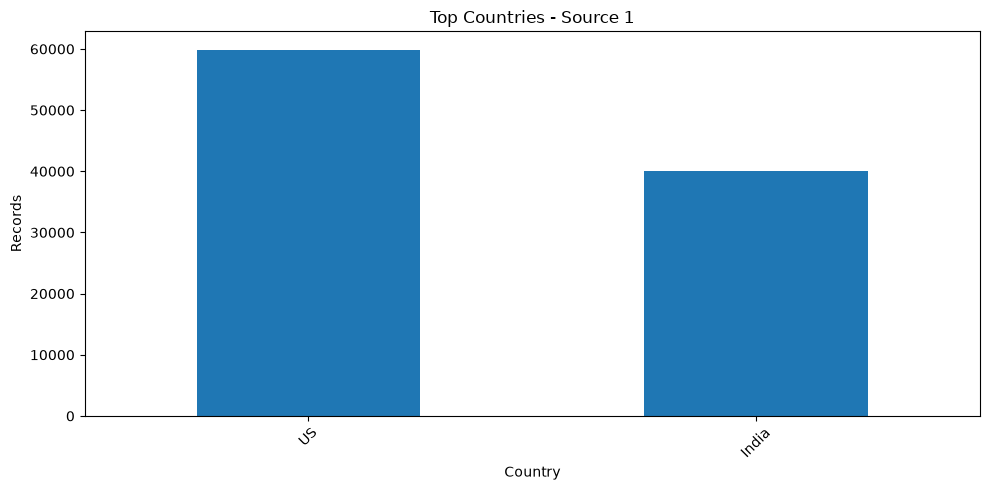


Source 2


country
US       59936
India    40064
Name: count, dtype: int64

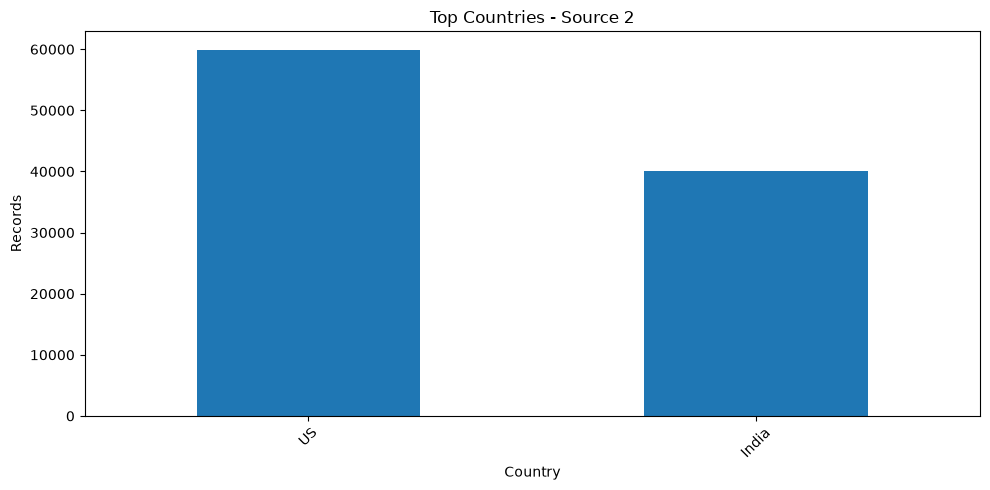


Source 3


country
US       59529
India    40471
Name: count, dtype: int64

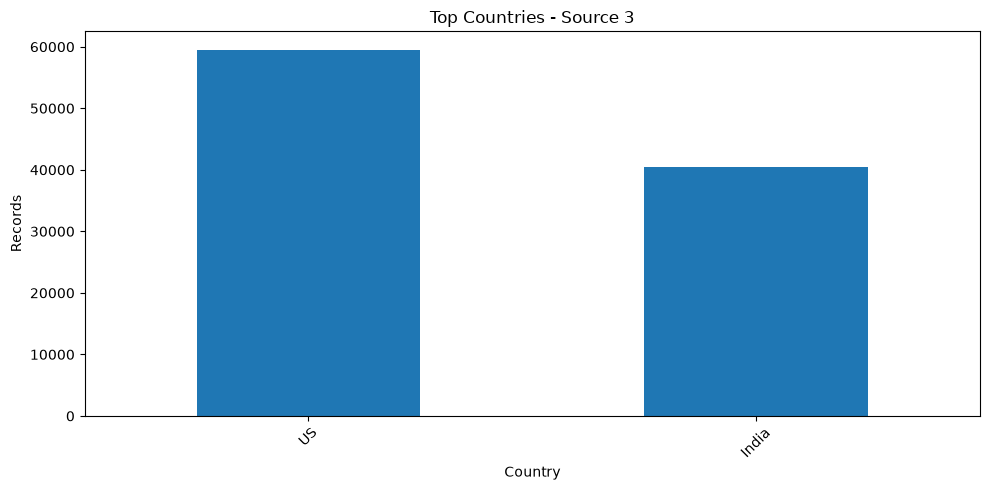

In [20]:
for name, df in datasets.items():

    if "country" in df.columns:

        print("\n", "=" * 70)
        print(name)
        print("=" * 70)

        country_counts = (
            df["country"]
            .fillna("MISSING")
            .value_counts()
            .head(20)
        )

        display(country_counts)

        plt.figure(figsize=(10, 5))

        country_counts.plot(
            kind="bar"
        )

        plt.title(
            f"Top Countries - {name}"
        )

        plt.xlabel("Country")
        plt.ylabel("Records")

        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

In [21]:
for name, df in datasets.items():

    if "entity_id" in df.columns:

        total = len(df)

        unique = df["entity_id"].nunique()

        duplicates = (
            df["entity_id"].duplicated().sum()
        )

        print(
            f"{name}: "
            f"total={total:,}, "
            f"unique IDs={unique:,}, "
            f"duplicate IDs={duplicates:,}"
        )

Source 1: total=100,000, unique IDs=100,000, duplicate IDs=0
Source 2: total=100,000, unique IDs=100,000, duplicate IDs=0
Source 3: total=100,000, unique IDs=100,000, duplicate IDs=0


In [22]:
summary = []

for name, df in datasets.items():

    summary.append({
        "Dataset": name,
        "Rows": len(df),
        "Columns": len(df.columns),
        "Duplicate Rows": df.duplicated().sum(),
        "Missing Cells": df.isna().sum().sum(),
        "Missing %": round(
            df.isna().mean().mean() * 100,
            2
        )
    })

summary_df = pd.DataFrame(summary)

display(summary_df)

,Dataset,Rows,Columns,Duplicate Rows,Missing Cells,Missing %
0,Source 1,100000,4,0,0,0.00
1,Source 2,100000,4,0,3330,0.83
2,Source 3,100000,4,0,3352,0.84
3,Ground Truth,100000,2,0,5594,2.80
